In [3]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/cleaned_dataset.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,8/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,12/6/2016,16/6/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,9/6/2014,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,9/6/2014,14/6/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [8]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# Generate summary metrics table
desc = df[num_cols].describe().T
desc['median'] = df[num_cols].median()
desc['mode'] = df[num_cols].mode().iloc[0]
desc['std_dev'] = df[num_cols].std()
desc['skewness'] = df[num_cols].skew()

summary_table = desc[['mean', 'median', 'mode', 'std_dev', 'skewness', 'min', 'max']]
print(summary_table)

               mean  median   mode    std_dev  skewness      min       max
Sales     68.003902  34.795  12.96  85.791669  2.349486   0.9900  496.8600
Quantity   3.373300   3.000   2.00   1.866236  1.003082   1.0000    9.0000
Discount   0.096273   0.000   0.00   0.105162  0.348981   0.0000    0.5000
Profit    11.669861   7.945   0.00  13.502676  0.858523 -26.8758   53.2704


In [9]:

consumer_sales = df[df['Segment'] == 'Consumer']['Sales']
corporate_sales = df[df['Segment'] == 'Corporate']['Sales']


t_stat, t_pval = stats.ttest_ind(consumer_sales.dropna(), corporate_sales.dropna())

print(f"Consumer Mean Sales: ${consumer_sales.mean():.2f}")
print(f"Corporate Mean Sales: ${corporate_sales.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {t_pval:.4f}")

Consumer Mean Sales: $69.70
Corporate Mean Sales: $68.39
T-statistic: 0.5390
P-value: 0.5899


In [10]:

contingency_table = pd.crosstab(df['Category'], df['Segment'])

# Chi-Square test
chi2, chi_pval, dof, expected = stats.chi2_contingency(contingency_table)

print("Contingency Table:\n", contingency_table)
print(f"\nChi2 Statistic: {chi2:.4f}")
print(f"P-value: {chi_pval:.4f}")
print(f"Degrees of Freedom: {dof}")

Contingency Table:
 Segment          Consumer  Corporate  Home Office
Category                                         
Furniture             611        352          196
Office Supplies      2366       1335          811
Technology            562        337          194

Chi2 Statistic: 1.3534
P-value: 0.8522
Degrees of Freedom: 4


In [11]:

sales_mean = df['Sales'].mean()
sales_sem = stats.sem(df['Sales'])
ci_sales = stats.t.interval(0.95, len(df['Sales']) - 1, loc=sales_mean, scale=sales_sem)

profit_mean = df['Profit'].mean()
profit_sem = stats.sem(df['Profit'])
ci_profit = stats.t.interval(0.95, len(df['Profit']) - 1, loc=profit_mean, scale=profit_sem)

print(f"Sales Mean: ${sales_mean:.2f} | 95% CI: (${ci_sales[0]:.2f}, ${ci_sales[1]:.2f})")
print(f"Profit Mean: ${profit_mean:.2f} | 95% CI: (${ci_profit[0]:.2f}, ${ci_profit[1]:.2f})")

Sales Mean: $68.00 | 95% CI: ($65.96, $70.05)
Profit Mean: $11.67 | 95% CI: ($11.35, $11.99)


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


cust_df = df.groupby('Customer ID').agg({
    'Sales': ['sum', 'mean', 'count'],
    'Profit': ['sum', 'mean'],
    'Discount': 'mean'
})

cust_df.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count', 'Total_Profit', 'Avg_Profit', 'Avg_Discount']
cust_df = cust_df.reset_index()

cust_df.head()

,Customer ID,Total_Sales,Avg_Sales,Order_Count,Total_Profit,Avg_Profit,Avg_Discount
0,AA-10315,596.980,74.622500,8,79.8089,9.976112,0.075000
1,AA-10375,556.410,39.743571,14,162.3870,11.599071,0.085714
2,AA-10480,652.732,72.525778,9,115.3212,12.813467,0.022222
3,AA-10645,702.860,58.571667,12,109.1827,9.098558,0.058333
4,AB-10015,322.216,80.554000,4,12.4785,3.119625,0.100000


In [13]:

X_clust = cust_df[['Total_Sales', 'Order_Count', 'Total_Profit', 'Avg_Discount']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

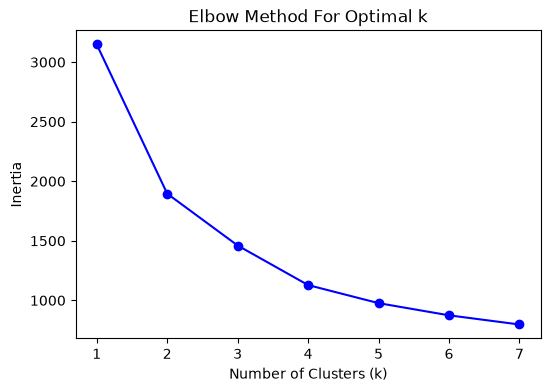

In [14]:
inertia = []
K_range = range(1, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

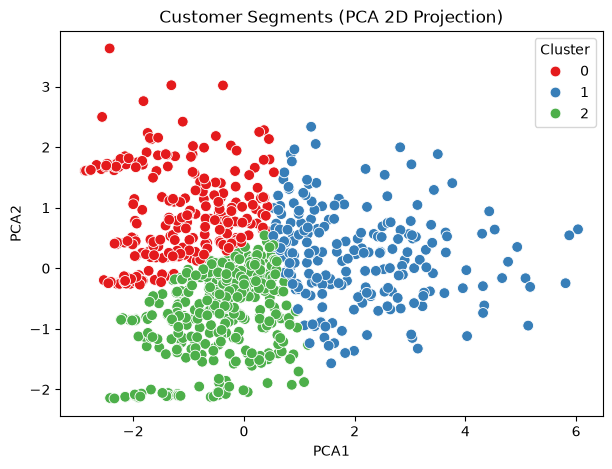

In [15]:

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cust_df['Cluster'] = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
cust_df['PCA1'] = pca_coords[:, 0]
cust_df['PCA2'] = pca_coords[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='Set1', data=cust_df, s=60)
plt.title('Customer Segments (PCA 2D Projection)')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, precision_score, recall_score

df_model = df[['Sales', 'Quantity', 'Discount', 'Profit', 'Category', 'Region', 'Segment']].copy()
df_model = pd.get_dummies(df_model, columns=['Category', 'Region', 'Segment'], drop_first=True)

In [17]:
X_reg = df_model.drop('Sales', axis=1)
y_reg = df_model['Sales']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_r, y_train_r)
y_pred_r = lr.predict(X_test_r)


print(f"R2 Score: {r2_score(y_test_r, y_pred_r):.4f}")
print(f"MAE: ${mean_absolute_error(y_test_r, y_pred_r):.2f}")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")

R2 Score: 0.3012
MAE: $43.40
RMSE: $70.71


In [18]:

df_class = df[['Sales', 'Quantity', 'Discount', 'Category', 'Region', 'Segment', 'Profit']].copy()
df_class['Is_Profitable'] = (df_class['Profit'] > 10).astype(int)
df_class = df_class.drop('Profit', axis=1)
df_class = pd.get_dummies(df_class, columns=['Category', 'Region', 'Segment'], drop_first=True)

X_clf = df_class.drop('Is_Profitable', axis=1)
y_clf = df_class['Is_Profitable']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


scaler_c = StandardScaler()
X_tr_c_scaled = scaler_c.fit_transform(X_train_c)
X_te_c_scaled = scaler_c.transform(X_test_c)

clf = LogisticRegression(random_state=42)
clf.fit(X_tr_c_scaled, y_train_c)
y_pred_c = clf.predict(X_te_c_scaled)


print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c) * 100:.2f}%")
print(f"Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"Recall: {recall_score(y_test_c, y_pred_c):.4f}")

Accuracy: 76.57%
Precision: 0.7572
Recall: 0.6490
